In [1]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [2]:
DECAY_RATE = 1

end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False)

df

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,Linear Velocity [m/s],Angular Velocity [rad/s],Image pixel 0,Image pixel 1,...,Image pixel 1192,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,experiment_path
0,0.000,-1.000000,None,-1.000000,1,1,0.273616,1.484229,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
0,0.000,0.933333,None,0.933333,1,2,0.348864,-0.891479,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
1,0.000,0.389474,None,1.322807,1,2,0.488137,-1.550437,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
2,0.132,0.540000,None,1.862807,1,2,0.126491,-0.204755,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
3,0.264,0.540000,None,2.402807,1,2,0.389691,-0.949269,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,8.118,0.200000,None,34.257453,1,26,0.015946,-1.136244,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
51,8.283,0.140000,None,34.397453,1,26,0.138649,-0.269769,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
52,8.448,-1.000000,None,33.397453,1,26,0.152133,1.540252,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
0,0.000,-1.000000,None,-1.000000,1,27,0.453851,1.549555,0.854902,0.854902,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...


In [8]:
exp_config = load_exp_config(df.experiment_path.values[0])

exp_type = exp_config["scenario"]["_target_"].split(".")[-1]
is_reset_buffer = exp_config["scenario"]["reset_rb_each_task"]
exp_name = f"{exp_type} reset_buffer: {is_reset_buffer}"

In [16]:
df.iteration_id.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

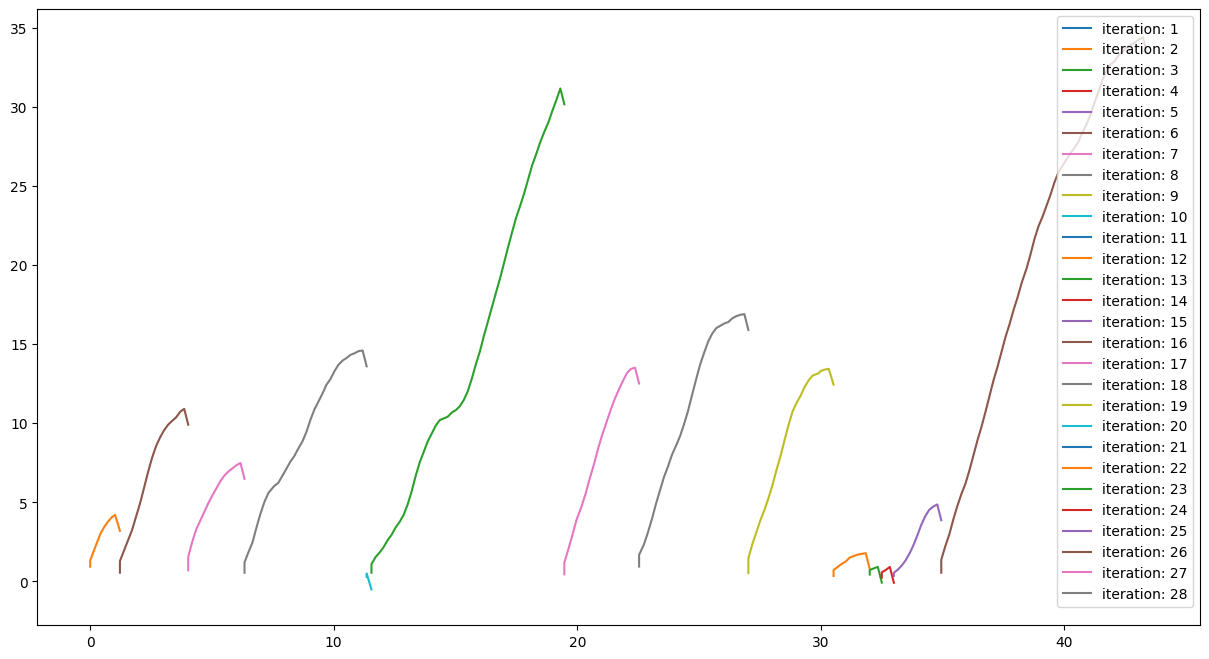

In [19]:
import matplotlib.pyplot as plt


last_sec = 0
fig, ax = plt.subplots(figsize=(15, 8))
for iter in df.iteration_id.unique():
    sub_df = df[df.iteration_id == iter]
    if sub_df.empty:
        continue
    
    ax.plot(sub_df.time + last_sec, sub_df.current_undiscounted_value, label=f"iteration: {iter}")
    last_sec += sub_df.time.max()
    # sub_df.plot(x="time", y="running_objective", ax=ax, label=f"iteration: {iter}")

ax.legend()

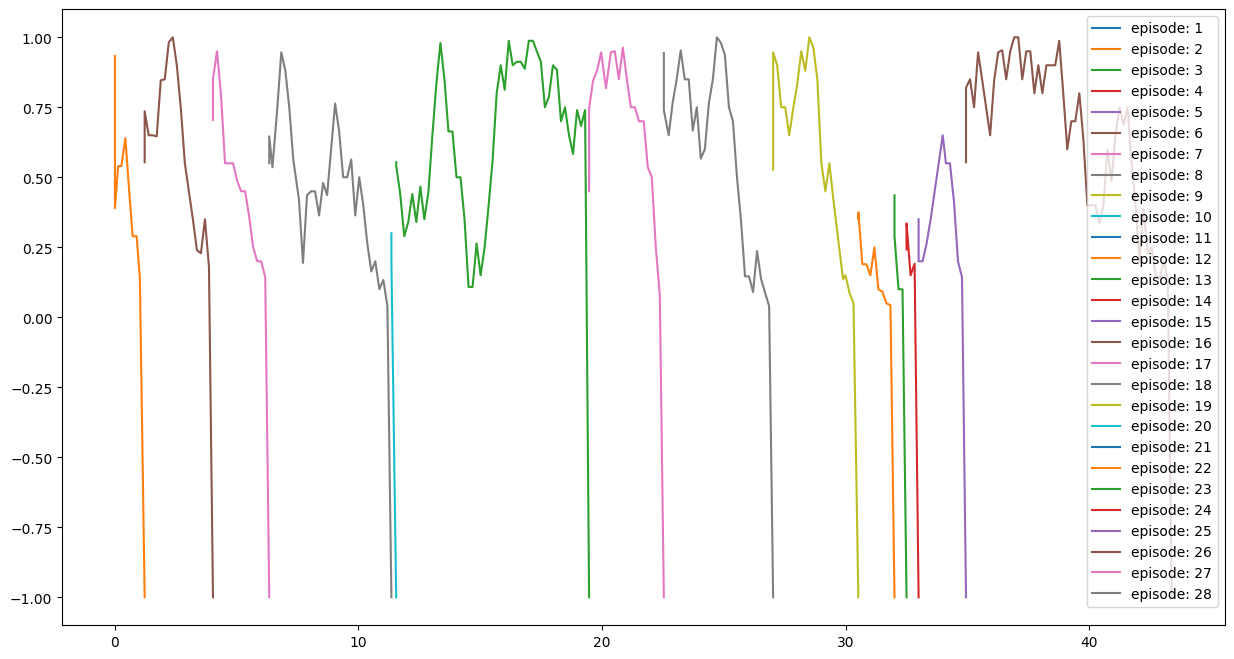

In [15]:
last_sec = 0
fig, ax = plt.subplots(figsize=(15, 8))
for iter in df.iteration_id.unique():
    sub_df = df[df.iteration_id == iter]
    if sub_df.empty:
        continue
    
    ax.plot(sub_df.time + last_sec, sub_df.running_objective, label=f"episode: {iter}")
    last_sec += sub_df.time.max()
    # sub_df.plot(x="time", y="running_objective", ax=ax, label=f"iteration: {iter}")

ax.legend()

Text(0, 0.5, 'Accumulated Reward')

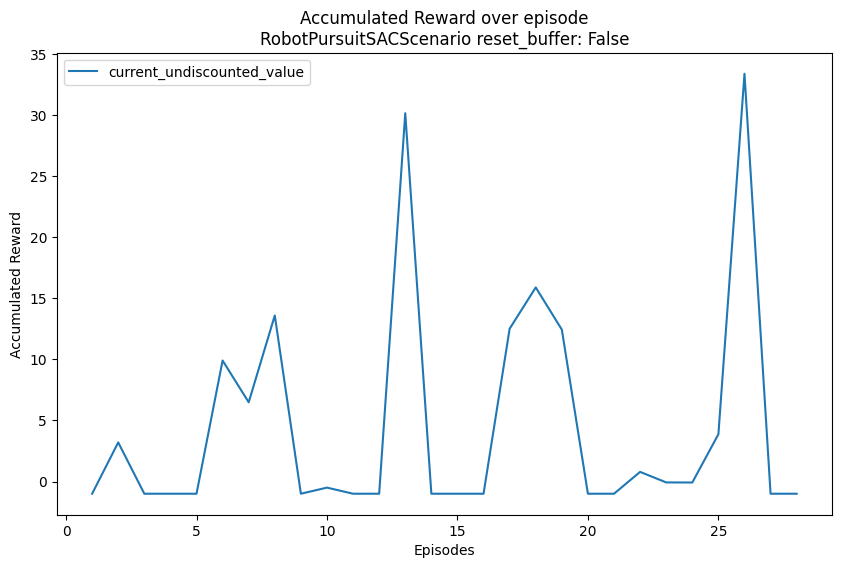

In [14]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 6))
group_df = df.groupby(["iteration_id"]).last()

group_df.reset_index().plot(x="iteration_id", y="current_undiscounted_value", ax=ax)
ax.set_title(f"Accumulated Reward over episode\n{exp_name}")
ax.set_xlabel("Episodes")
ax.set_ylabel("Accumulated Reward")